# Phase 1 — Shared Data Preparation
**VizWiz-Captions | Deep Learning AT3**

Run this notebook **once as a group**. It covers:

1. EDA — Explore dataset structure and statistics
2. Clean & tokenise captions
3. Build vocabulary (word2idx / idx2word)
4. Create train / val / test splits (fixed seed)
5. Implement VizWizDataset class & DataLoader with collate_fn
6. Verify end-to-end data pipeline (test batch)

## 0. Install dependencies

In [24]:
!pip install -q torch torchvision tqdm nltk pandas Pillow matplotlib

## 1. Mount Google Drive & set up folders

In [25]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# ── Shared Drive paths ────────────────────────────────────────────────────────
DRIVE_FOLDER    = Path('/content/drive/MyDrive/AT3-DL-ImageCaptioning')
DRIVE_RAW       = DRIVE_FOLDER / 'raw'
DRIVE_PROCESSED = DRIVE_FOLDER / 'processed'
DRIVE_IMAGES    = DRIVE_PROCESSED / 'images_224'

# ── Colab ephemeral workspace (fast local I/O during processing) ──────────────
COLAB_RAW       = Path('/content/data/raw')
COLAB_PROCESSED = Path('/content/data/processed')
COLAB_IMAGES    = COLAB_PROCESSED / 'images_224'

for p in [DRIVE_FOLDER, DRIVE_RAW, DRIVE_PROCESSED, DRIVE_IMAGES,
          COLAB_RAW, COLAB_PROCESSED, COLAB_IMAGES]:
    p.mkdir(parents=True, exist_ok=True)

print('Drive folder:', DRIVE_FOLDER)
print('Drive writable:', DRIVE_PROCESSED.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive folder: /content/drive/MyDrive/AT3-DL-ImageCaptioning
Drive writable: True


## 2. Download dataset into Colab workspace

Downloads go to `/content/data/raw/` — ephemeral, fast, local to this Colab instance.

In [26]:
# Images (~2 GB) — skipped if already downloaded
if not any(COLAB_RAW.rglob('*.jpg')):
    !wget -q --show-progress https://vizwiz.cs.colorado.edu/VizWiz_final/images/val.zip \
          -O /content/data/raw/val.zip
    !unzip -q /content/data/raw/val.zip -d /content/data/raw/
    !rm /content/data/raw/val.zip
    print('Images downloaded and extracted.')
else:
    print('Images already present — skipping download.')

# Annotations — skipped if already downloaded
if not any(COLAB_RAW.rglob('*.json')):
    !wget -q --show-progress https://vizwiz.cs.colorado.edu/VizWiz_final/caption/annotations.zip \
          -O /content/data/raw/annotations.zip
    !unzip -q /content/data/raw/annotations.zip -d /content/data/raw/
    !rm /content/data/raw/annotations.zip
    print('Annotations downloaded and extracted.')
else:
    print('Annotations already present — skipping download.')

Images already present — skipping download.
Annotations already present — skipping download.


In [27]:
# Verify download — detect where images actually landed (zip may extract to a subdirectory)
jpg_files = list(COLAB_RAW.rglob('*.jpg'))
assert jpg_files, f'No .jpg files found under {COLAB_RAW}'
IMG_DIR = jpg_files[0].parent  # all images are siblings, take the parent of any one
n_images = len(jpg_files)
print(f'Images found : {n_images}  (in {IMG_DIR})')

annot_files = list(COLAB_RAW.rglob('*.json'))
print(f'Annotation files: {[str(f.relative_to(COLAB_RAW)) for f in annot_files]}')

Images found : 7750  (in /content/data/raw/val)
Annotation files: ['annotations/train.json', 'annotations/val.json', 'annotations/test.json']


## 3. Imports & reproducibility

In [28]:
import json
import random
import pickle
import string
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torchvision.transforms as T
from tqdm.auto import tqdm

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## 1. EDA — Explore dataset structure and statistics

Before building any pipeline, understand the data: shapes, distributions, anomalies.

In [29]:
# The annotations.zip contains both train.json and val.json.
# We must load val.json — train.json references VizWiz_train_* files
# which don't exist in the val image zip we downloaded.
all_jsons = list(COLAB_RAW.rglob('*.json'))
assert all_jsons, f'No JSON found under {COLAB_RAW}'
print('JSON files found:', [str(f.relative_to(COLAB_RAW)) for f in all_jsons])

# Prefer val.json; fall back to first found
val_jsons = [f for f in all_jsons if f.stem == 'val']
ANNOT_FILE = val_jsons[0] if val_jsons else all_jsons[0]
print('Using annotation file:', ANNOT_FILE)

with open(ANNOT_FILE) as f:
    raw_data = json.load(f)

print('Top-level keys  :', list(raw_data.keys()))
print('Sample image    :', raw_data['images'][0])
print('Sample annotation:', raw_data['annotations'][0])

JSON files found: ['annotations/train.json', 'annotations/val.json', 'annotations/test.json']
Using annotation file: /content/data/raw/annotations/val.json
Top-level keys  : ['info', 'images', 'annotations']
Sample image    : {'file_name': 'VizWiz_val_00000000.jpg', 'vizwiz_url': 'https://ivc.ischool.utexas.edu/VizWiz_visualization_img/VizWiz_val_00000000.jpg', 'id': 23431, 'text_detected': True}
Sample annotation: {'caption': 'A computer screen shows a repair prompt on the screen.', 'image_id': 23431, 'is_precanned': False, 'is_rejected': False, 'id': 117155, 'text_detected': True}


In [30]:
images_meta = {img['id']: img['file_name'] for img in raw_data['images']}

records = []
for ann in raw_data['annotations']:
    records.append({
        'image_id':  ann['image_id'],
        'file_name': images_meta[ann['image_id']],
        'caption':   ann['caption'],
    })

df = pd.DataFrame(records)
print(f'Total caption rows : {len(df):,}')
print(f'Unique images      : {df["image_id"].nunique():,}')
df.head()

Total caption rows : 38,750
Unique images      : 7,750


,image_id,file_name,caption
0,23431,VizWiz_val_00000000.jpg,A computer screen shows a repair prompt on the...
1,23431,VizWiz_val_00000000.jpg,a computer screen with a repair automatically ...
2,23431,VizWiz_val_00000000.jpg,partial computer screen showing the need of re...
3,23431,VizWiz_val_00000000.jpg,Part of a computer monitor showing a computer ...
4,23431,VizWiz_val_00000000.jpg,The top of a laptop with a blue background and...


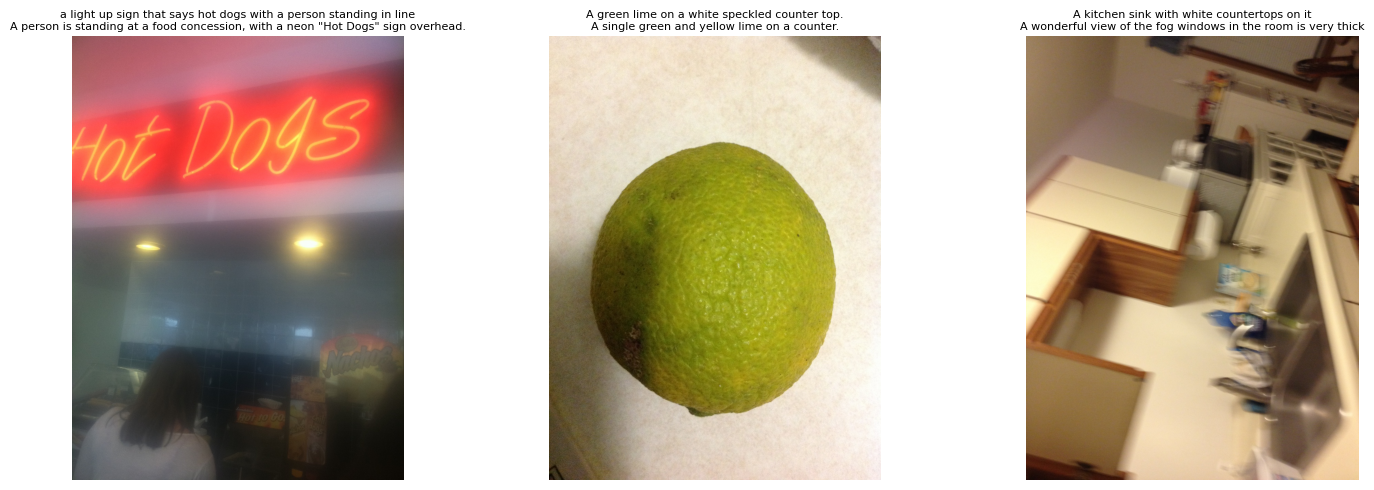

In [31]:
# Quick visual sample
sample_ids = df['image_id'].drop_duplicates().sample(3, random_state=SEED).tolist()
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, img_id in zip(axes, sample_ids):
    fname = images_meta[img_id]
    img = Image.open(IMG_DIR / fname).convert('RGB')
    caps = df[df['image_id'] == img_id]['caption'].tolist()
    ax.imshow(img)
    ax.set_title('\n'.join(caps[:2]), fontsize=8, wrap=True)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [32]:
def explore_dataset(df, raw_data):
    # TODO: print total number of images and total number of captions
    # TODO: print average, min, and max number of captions per image
    # TODO: print distribution of raw caption lengths (word count) — use df['caption'].str.split().map(len)
    # TODO: plot a histogram of caption lengths
    # TODO: print the 10 most and 10 least frequent words across all captions
    # TODO: print how many captions contain the literal word 'unanswerable'
    # TODO: print how many annotations have is_rejected == True (check raw_data['annotations'])
    pass

explore_dataset(df, raw_data)

## 2. Clean & tokenise captions

**Standard cleaning steps:**
- Lowercase, remove punctuation
- Tokenise with `nltk.word_tokenize()`
- Tokens will be extended with `<SOS>`, `<EOS>`, `<PAD>`, `<UNK>` at DataLoader time

**⚠️ VizWiz-specific filters (critical):**
- Filter captions with `is_rejected: true` or literal text `'unanswerable'`
- Filter captions < 3 tokens after cleaning (pure noise)
- Filter captions > 50 tokens (outliers that distort padding)
- Filter captions that consist only of stopwords after cleaning

> Read the actual JSON structure (EDA cell above) before implementing — confirm exact field names.

In [33]:
def clean_caption(text: str) -> list:
    text = text.lower().strip()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return nltk.word_tokenize(text)

df['tokens'] = df['caption'].apply(clean_caption)

before = len(df)
df = df[df['tokens'].map(len) > 0].copy()
print(f'Removed {before - len(df)} empty captions after cleaning')
print(f'Remaining: {len(df):,} captions across {df["image_id"].nunique():,} images')
df[['caption', 'tokens']].head(3)

Removed 0 empty captions after cleaning
Remaining: 38,750 captions across 7,750 images


,caption,tokens
0,A computer screen shows a repair prompt on the...,"[a, computer, screen, shows, a, repair, prompt..."
1,a computer screen with a repair automatically ...,"[a, computer, screen, with, a, repair, automat..."
2,partial computer screen showing the need of re...,"[partial, computer, screen, showing, the, need..."


In [34]:
def inspect_vizwiz_fields(raw_data):
    # TODO: print all top-level keys found in raw_data
    # TODO: print the raw content of the first 3 entries in raw_data['annotations']
    # TODO: confirm the exact field name used for the rejection flag (e.g. 'is_rejected')
    pass

inspect_vizwiz_fields(raw_data)

In [35]:
def filter_unanswerable(df):
    # TODO: remove rows where the rejection field is True
    #       build a lookup from raw_data['annotations'] keyed by (image_id, caption)
    #       use .get('is_rejected', False) to handle releases where the field is absent
    #       add the flag as a column to df, then drop rows where it is True
    # TODO: remove rows where df['caption'].str.strip().str.lower() == 'unanswerable'
    # TODO: print how many captions were removed in this step
    # TODO: return the filtered DataFrame
    return df  # placeholder — replace with real implementation

df = filter_unanswerable(df)


In [36]:
MIN_LEN = 3   # minimum tokens after cleaning
MAX_LEN = 50  # maximum tokens after cleaning

def filter_by_length(df, min_len=MIN_LEN, max_len=MAX_LEN):
    # TODO: remove rows where len(df['tokens']) < min_len
    # TODO: print how many captions were removed by the min_len threshold
    # TODO: remove rows where len(df['tokens']) > max_len
    # TODO: print how many captions were removed by the max_len threshold
    # TODO: return the filtered DataFrame
    return df  # placeholder — replace with real implementation

df = filter_by_length(df)


In [37]:
def filter_stopwords_only(df):
    # TODO: load English stopwords from nltk.corpus.stopwords
    # TODO: remove rows where every token in df['tokens'] is a stopword
    # TODO: print how many captions were removed
    # TODO: return the filtered DataFrame
    return df  # placeholder — replace with real implementation

df = filter_stopwords_only(df)


In [38]:
original_count = None  # TODO: assign len(df) BEFORE calling any filter_* function above

def summarise_filtering(original_count, df):
    # TODO: print total captions before filtering (original_count)
    # TODO: print total captions after all filters (len(df))
    # TODO: print percentage removed
    # TODO: plot a histogram of token counts (df['tokens'].map(len)) after filtering
    pass

summarise_filtering(original_count, df)

## 3. Build vocabulary (word2idx / idx2word)

Special tokens: `<PAD>=0  <SOS>=1  <EOS>=2  <UNK>=3`  
Words appearing fewer than `FREQ_THRESHOLD` times are mapped to `<UNK>`.

In [39]:
FREQ_THRESHOLD = 5                                    # TODO: adjust minimum word frequency if needed
SPECIAL_TOKENS = ['<PAD>', '<SOS>', '<EOS>', '<UNK>'] # TODO: add or rename special tokens if your architecture requires it
PAD_IDX, SOS_IDX, EOS_IDX, UNK_IDX = 0, 1, 2, 3

def build_vocabulary(df, freq_threshold=FREQ_THRESHOLD):
    # TODO: flatten all token lists from df['tokens'] into a single list
    # TODO: count token frequencies using Counter
    # TODO: keep only tokens that appear >= freq_threshold times
    # TODO: sort the surviving words (for deterministic ordering)
    # TODO: build word2idx starting with SPECIAL_TOKENS, then append vocab words
    # TODO: build idx2word as the inverse mapping
    # TODO: return word2idx, idx2word, and the frequency Counter
    return {}, {}, Counter()  # placeholder — replace with real implementation

word2idx, idx2word, freq = build_vocabulary(df)

vocab = {
    'word2idx':       word2idx,
    'idx2word':       idx2word,
    'freq_threshold': FREQ_THRESHOLD,
    'special_tokens': SPECIAL_TOKENS,
    'PAD_IDX':        PAD_IDX,
    'SOS_IDX':        SOS_IDX,
    'EOS_IDX':        EOS_IDX,
    'UNK_IDX':        UNK_IDX,
}

# TODO: print vocabulary size (len(word2idx))
# TODO: print total unique tokens before frequency threshold (len(freq))

## 4. Create train / val / test splits (fixed seed)

Split at the **image level** (80 / 10 / 10) — no image appears in two sets.

In [40]:
image_ids = df['image_id'].drop_duplicates().tolist()
random.shuffle(image_ids)

n       = len(image_ids)
n_train = int(0.8 * n)
n_val   = int(0.1 * n)

splits = {
    'train': image_ids[:n_train],
    'val':   image_ids[n_train:n_train + n_val],
    'test':  image_ids[n_train + n_val:],
}

print(f'Train : {len(splits["train"]):,} images')
print(f'Val   : {len(splits["val"]):,} images')
print(f'Test  : {len(splits["test"]):,} images')

Train : 6,200 images
Val   : 775 images
Test  : 775 images


## 5. Implement VizWizDataset class & DataLoader with collate_fn

In [41]:
class VizWizDataset:
    # TODO: inherit from torch.utils.data.Dataset
    # TODO: __init__(self, image_ids, captions, id_to_filename, img_dir, word2idx, transform=None)
    #         - build self.samples: list of (img_path, token_index_list) for every (image, caption) pair
    #         - prepend SOS_IDX and append EOS_IDX to each token index list
    #         - map unknown tokens to UNK_IDX using word2idx.get(token, UNK_IDX)
    #         - set self.transform to the provided transform or a default:
    #             T.Compose([T.ToTensor(), T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])])
    # TODO: __len__(self) — return len(self.samples)
    # TODO: __getitem__(self, idx)
    #         - open image with PIL, convert to RGB
    #         - apply self.transform
    #         - return (image_tensor, torch.tensor(caption_indices, dtype=torch.long))
    pass


def collate_fn(batch):
    # TODO: unzip batch into (images, captions)
    # TODO: stack images into a single tensor
    # TODO: pad caption tensors to the same length within the batch (use PAD_IDX)
    # TODO: return (images, captions_padded, lengths) where lengths is a tensor of original lengths
    pass

In [42]:
BATCH_SIZE = 32

# TODO: build id_to_filename dict: str(image_id) → file_name from df

# TODO: instantiate VizWizDataset for train, val, and test splits
#        use splits['train'], splits['val'], splits['test']
#        pass id_to_filename, DRIVE_IMAGES, word2idx

# TODO: wrap each dataset in a DataLoader
#        train: shuffle=True, batch_size=BATCH_SIZE, collate_fn=collate_fn, num_workers=2
#        val / test: shuffle=False

# TODO: print number of batches in train, val, test loaders

## 6. Verify end-to-end data pipeline (test batch)

In [43]:
def verify_pipeline(train_loader):
    # TODO: fetch one batch from train_loader using next(iter(train_loader))
    # TODO: print images.shape  — expected: (BATCH_SIZE, 3, 224, 224)
    # TODO: print captions.shape — expected: (BATCH_SIZE, max_seq_len)
    # TODO: print lengths        — expected: 1-D tensor of length BATCH_SIZE
    # TODO: decode and print the first caption in the batch using idx2word
    #         (map each index → word, stop at EOS_IDX)
    # TODO: display the first image in the batch (reverse the normalisation before imshow)
    pass

# Skipped until VizWizDataset and DataLoaders are implemented (section 6)
if 'train_loader' in dir():
    verify_pipeline(train_loader)
else:
    print('train_loader not yet defined — implement section 6 first.')

train_loader not yet defined — implement section 6 first.


## 7. Save processed artefacts to shared Google Drive

This step makes everything available to all team members.

In [44]:
import shutil

# vocab.pkl
with open(DRIVE_PROCESSED / 'vocab.pkl', 'wb') as f:
    pickle.dump(vocab, f)
print('Uploaded vocab.pkl')

# splits.json
with open(DRIVE_PROCESSED / 'splits.json', 'w') as f:
    json.dump(splits, f)
print('Uploaded splits.json')

# captions_clean.json
captions_clean = defaultdict(list)
for _, row in df.iterrows():
    captions_clean[str(row['image_id'])].append(row['tokens'])

id_to_filename = {
    str(k): v
    for k, v in df[['image_id', 'file_name']]
        .drop_duplicates()
        .set_index('image_id')['file_name']
        .to_dict()
        .items()
}

with open(DRIVE_PROCESSED / 'captions_clean.json', 'w') as f:
    json.dump({'captions': dict(captions_clean), 'id_to_filename': id_to_filename}, f)
print('Uploaded captions_clean.json')

Uploaded vocab.pkl
Uploaded splits.json
Uploaded captions_clean.json


In [45]:
# images_224/ — largest step, several minutes
for img_path in tqdm(list(COLAB_IMAGES.glob('*.jpg')), desc='Uploading images to Drive'):
    dst = DRIVE_IMAGES / img_path.name
    if not dst.exists():
        shutil.copy(img_path, dst)

print(f'Images on Drive: {len(list(DRIVE_IMAGES.glob("*.jpg"))):,}')

Uploading images to Drive: 0it [00:00, ?it/s]

Images on Drive: 0


## 8. Final verification

In [46]:
print('=== Drive artefacts ===')
for p in [DRIVE_PROCESSED / 'vocab.pkl',
          DRIVE_PROCESSED / 'splits.json',
          DRIVE_PROCESSED / 'captions_clean.json']:
    status = 'OK' if p.exists() else 'MISSING'
    size   = f'{p.stat().st_size / 1024:.1f} KB' if p.exists() else '—'
    print(f'  [{status}] {p.name} ({size})')

n_imgs = len(list(DRIVE_IMAGES.glob('*.jpg')))
print(f'  [OK] images_224/ — {n_imgs:,} images')
print()
print('Done. Student notebooks can now mount Drive and read from processed/')

=== Drive artefacts ===
  [OK] vocab.pkl (0.2 KB)
  [OK] splits.json (53.0 KB)
  [OK] captions_clean.json (4093.8 KB)
  [OK] images_224/ — 0 images

Done. Student notebooks can now mount Drive and read from processed/
